In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
data=pd.read_csv('Ice_cream selling data.csv')

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

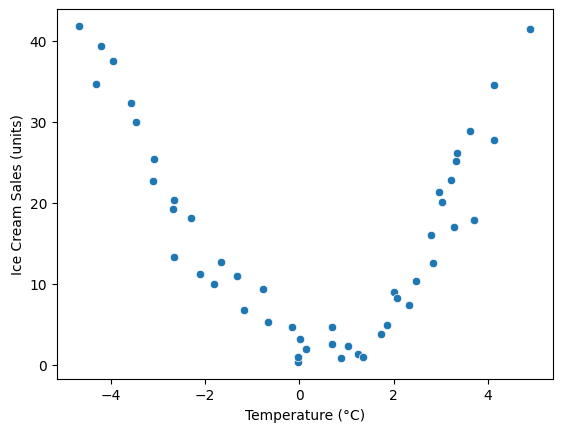

In [74]:
sns.scatterplot(x='Temperature (°C)',y='Ice Cream Sales (units)',data=data)

In [75]:
#remove duplicates
data.drop_duplicates(inplace=True)

In [76]:
q1=data['Temperature (°C)'].quantile(0.25)
q3=data['Temperature (°C)'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
data=data[(data['Temperature (°C)']>=lower_bound)&(data['Temperature (°C)']<=upper_bound)]

In [77]:
x=data['Temperature (°C)']
y=data['Ice Cream Sales (units)']

In [78]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Temperature (°C)']=le.fit_transform(data['Temperature (°C)'])

In [79]:
data

,Temperature (°C),Ice Cream Sales (units)
0,0,41.842986
1,1,34.661120
2,2,39.383001
3,3,37.539845
4,4,32.284531
5,5,30.001138
6,6,22.635401
7,7,25.365022
8,8,19.226970
9,9,20.279679


In [80]:
#normalization
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data['Temperature (°C)']=scaler.fit_transform(data[['Temperature (°C)']])

In [81]:
data

,Temperature (°C),Ice Cream Sales (units)
0,0.000000,41.842986
1,0.020833,34.661120
2,0.041667,39.383001
3,0.062500,37.539845
4,0.083333,32.284531
5,0.104167,30.001138
6,0.125000,22.635401
7,0.145833,25.365022
8,0.166667,19.226970
9,0.187500,20.279679


In [82]:
#normalization
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data['Ice Cream Sales (units)']=scaler.fit_transform(data[['Ice Cream Sales (units)']])

In [83]:
data

,Temperature (°C),Ice Cream Sales (units)
0,0.000000,1.000000
1,0.020833,0.827003
2,0.041667,0.940744
3,0.062500,0.896346
4,0.083333,0.769755
5,0.104167,0.714753
6,0.125000,0.537327
7,0.145833,0.603078
8,0.166667,0.455224
9,0.187500,0.480582


In [84]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degree = 2
poly = PolynomialFeatures(degree)

# Reshape x to be a 2D array
X_poly = poly.fit_transform(x.values.reshape(-1, 1))

model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [85]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=model.predict(X_poly)
r2=r2_score(y,y_pred)
mae=mean_absolute_error(y,y_pred)
mse=mean_squared_error(y,y_pred)
print('MAE:',mae)
print('MSE:',mse)
print('r2:',r2)

MAE: 2.697154846603795
MSE: 10.00322059498249
r2: 0.9321137090423877
